In [1]:
# ==== Imports ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
# ==== Load and preprocess data ====
file_path = "/content/crime(om).csv"
crime_data = pd.read_csv(file_path)

In [3]:
# Select features (latitude & longitude)
X = crime_data[['latitude', 'longitude']].values

In [4]:
# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# ==== Print scores ====
print("KMeans Silhouette Score:", kmeans_score)
print("DBSCAN Silhouette Score:", dbscan_score)

KMeans Silhouette Score: 0.3615501347634504
DBSCAN Silhouette Score: -1


In [24]:
# ==== Utility functions ====
def run_kmeans(X, n_clusters=4, random_state=42):
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    return labels, score

def run_dbscan(X, eps=0.3, min_samples=5):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X)
    score = silhouette_score(X, labels) if len(set(labels)) > 1 else -1
    return labels, score

def plot_clusters(X, labels, title, cmap="viridis"):
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap=cmap, s=10)
    plt.title(title)
    plt.xlabel("Latitude")
    plt.ylabel("Longitude")

In [25]:
# ==== Run clustering ====
kmeans_labels, kmeans_score = run_kmeans(X_scaled, n_clusters=4)
dbscan_labels, dbscan_score = run_dbscan(X_scaled, eps=0.3, min_samples=5)

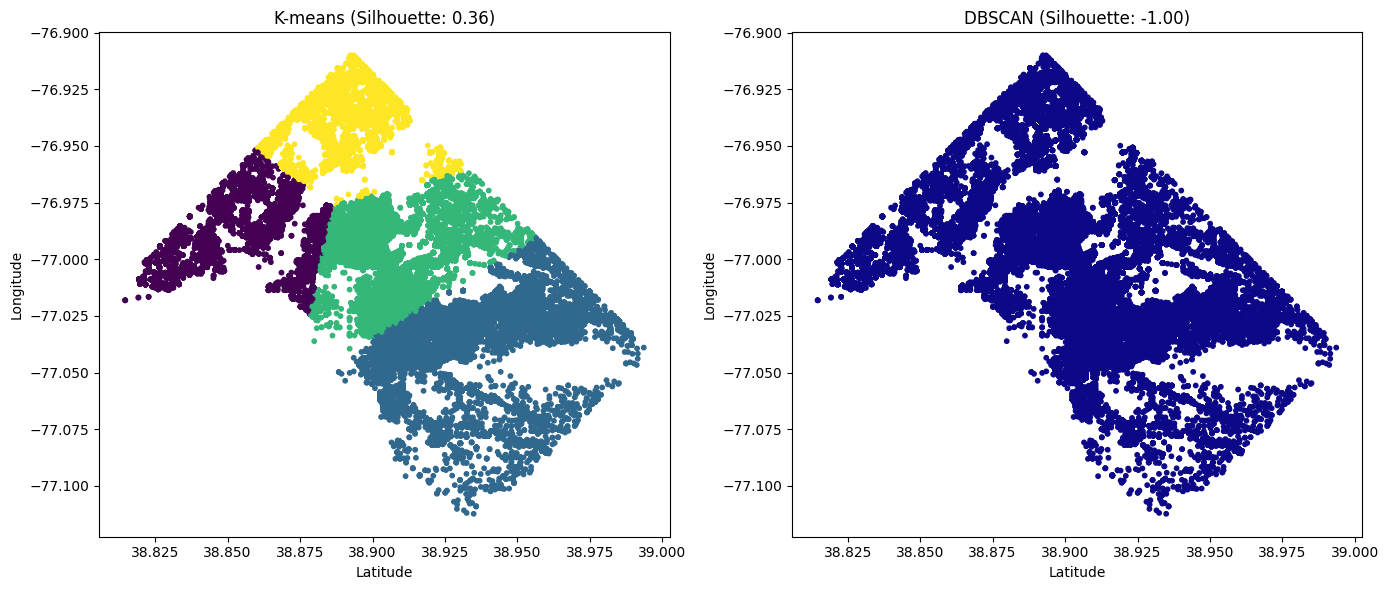

In [26]:
# ==== Plot results side by side ====
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plt.sca(axes[0])
plot_clusters(X, kmeans_labels, f"K-means (Silhouette: {kmeans_score:.2f})", cmap="viridis")

plt.sca(axes[1])
plot_clusters(X, dbscan_labels, f"DBSCAN (Silhouette: {dbscan_score:.2f})", cmap="plasma")

plt.tight_layout()
plt.show()

In [27]:
# ==== Print scores ====
print("KMeans Silhouette Score:", kmeans_score)
print("DBSCAN Silhouette Score:", dbscan_score)


KMeans Silhouette Score: 0.3615501347634504
DBSCAN Silhouette Score: -1


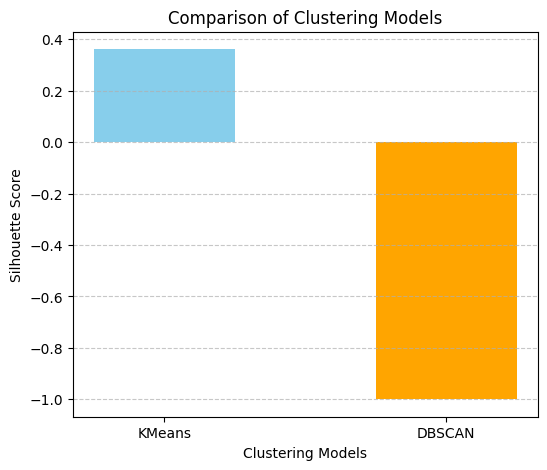

In [13]:
# ==== Bar Plot Comparison (KMeans vs DBSCAN) ====
models = ['KMeans', 'DBSCAN']
scores = [kmeans_score, dbscan_score]

plt.figure(figsize=(6, 5))
plt.bar(models, scores, color=['skyblue', 'orange'], width=0.5)

plt.xlabel('Clustering Models')
plt.ylabel('Silhouette Score')
plt.title('Comparison of Clustering Models')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()